## Part A - Data Loading and Preprocessing with Scikit-learn
### Task 1 - Load and Understand the Dataset

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("hotel_bookings.csv")

# 1. View first 5 rows
print("First 5 rows:")
display(df.head())

# 2. Dataset shape
print("Shape:", df.shape)

# 3. Dataset information
print("\nDataset Info:")
df.info()

# 4. Statistical summary
print("\nDescriptive Statistics:")
display(df.describe())

# 5. Data types
print("\nData Types:")
print(df.dtypes)

# 6. Class distribution of target variable
print("\nClass Distribution of is_canceled:")
print(df["is_canceled"].value_counts())
print("\nClass Distribution (%):")
print(df["is_canceled"].value_counts(normalize=True) * 100)

# 7. Define target variable
y = df["is_canceled"]

# 8. Create feature set by removing target
X = df.drop(columns=["is_canceled"])

# 9. Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("\nNumerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

print("\nNumber of numerical columns:", len(numerical_cols))
print("Number of categorical columns:", len(categorical_cols))

First 5 rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


Shape: (119390, 32)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000



Data Types:
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                

### Task 2 - Missing Values, Leakage, and Outliers

Missing Value Summary:


,Missing Count,Missing Percentage
children,4,0.003350
country,488,0.408744
agent,16340,13.686238
company,112593,94.306893


Columns with more than 50% missing values:


,Missing Count,Missing Percentage
company,112593,94.306893


Leakage columns removed.


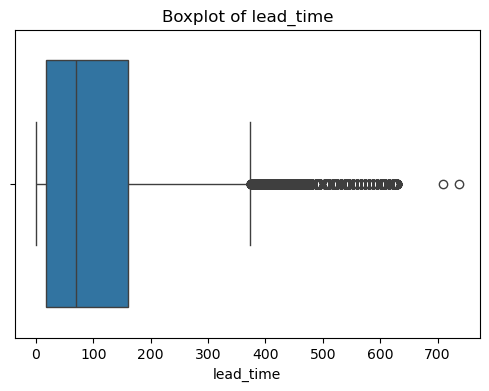

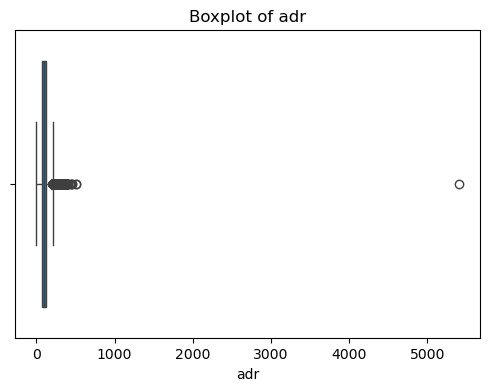

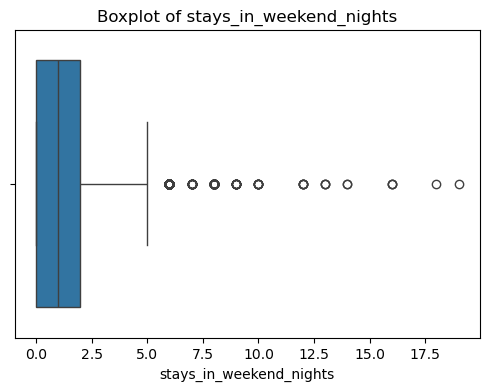

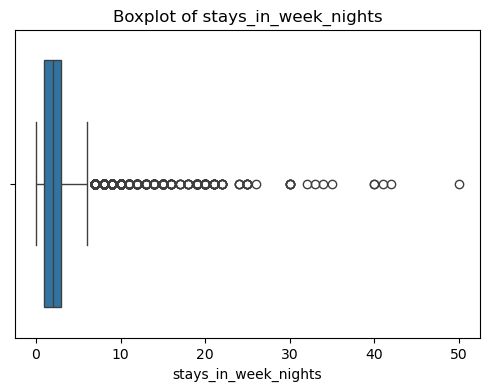

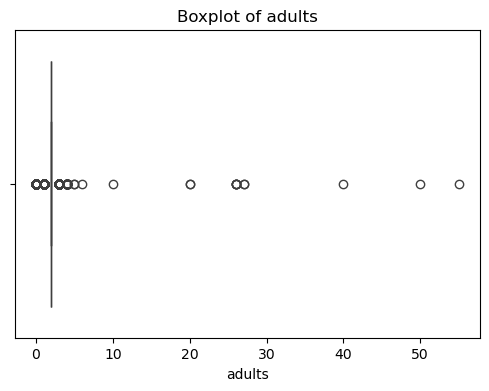

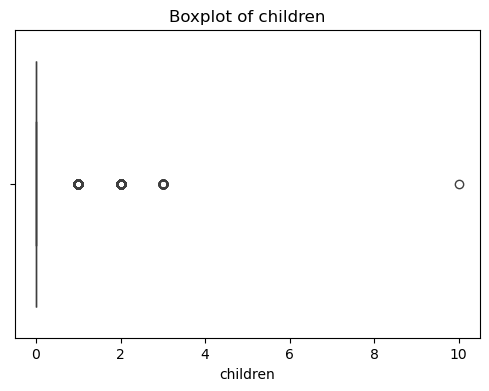

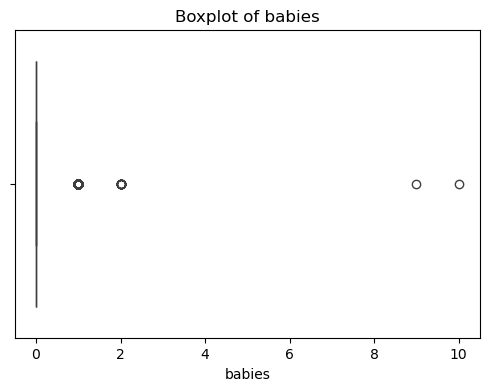

Rows removed due to extreme/invalid outliers: 1
Final dataset shape: (119389, 29)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 1. Missing value analysis
# -----------------------------

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

print("Missing Value Summary:")
display(missing_summary[missing_summary["Missing Count"] > 0])


# -----------------------------
# 2. High missingness
# -----------------------------

high_missing = missing_summary[
    missing_summary["Missing Percentage"] > 50
]

print("Columns with more than 50% missing values:")
display(high_missing)

# Drop company because of very high missingness
df = df.drop(columns=["company"])


# -----------------------------
# 3. Remove leakage columns
# -----------------------------

df = df.drop(
    columns=["reservation_status", "reservation_status_date"]
)

print("Leakage columns removed.")


# -----------------------------
# 4. Check outliers
# -----------------------------

numerical_features = [
    "lead_time",
    "adr",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies"
]

for column in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()


# -----------------------------
# 5. Remove clear invalid values
# -----------------------------

before = len(df)

# ADR should not be negative
df = df[df["adr"] >= 0]

after = len(df)

print("Rows removed due to extreme/invalid outliers:", before - after)

print("Final dataset shape:", df.shape)

### Task 3 - Create Two Preprocessing Pipelines

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# ---------------------------------
# 1. Create X and y
# ---------------------------------

y = df["is_canceled"]
X = df.drop(columns=["is_canceled"])


# ---------------------------------
# 2. Identify numerical and categorical columns
# ---------------------------------

numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()


# ---------------------------------
# 3. Train-test split
# ---------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


# ---------------------------------
# 4. Numerical preprocessing - Pipeline A
# ---------------------------------

numerical_pipeline_A = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])


# ---------------------------------
# 5. Numerical preprocessing - Pipeline B
# ---------------------------------

numerical_pipeline_B = Pipeline([
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])


# ---------------------------------
# 6. Categorical preprocessing
# ---------------------------------

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


# ---------------------------------
# 7. Pipeline A using ColumnTransformer
# ---------------------------------

preprocessor_A = ColumnTransformer([
    ("num", numerical_pipeline_A, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])


# ---------------------------------
# 8. Pipeline B using ColumnTransformer
# ---------------------------------

preprocessor_B = ColumnTransformer([
    ("num", numerical_pipeline_B, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])


print("Pipeline A: KNNImputer + StandardScaler")
print("Pipeline B: KNNImputer + MinMaxScaler")

Training set: (95511, 28)
Testing set: (23878, 28)
Pipeline A: KNNImputer + StandardScaler
Pipeline B: KNNImputer + MinMaxScaler


## Part B - Model Training and Performance Evaluation
### Task 4 - Train Two Classification Models

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

# ---------------------------------
# 1. Logistic Regression + Pipeline A
# ---------------------------------

logistic_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_A.fit(X_train, y_train)


# ---------------------------------
# 2. Logistic Regression + Pipeline B
# ---------------------------------

logistic_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_B.fit(X_train, y_train)


# ---------------------------------
# 3. Decision Tree + Pipeline A
# ---------------------------------

tree_A = Pipeline([
    ("preprocessor", preprocessor_A),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_A.fit(X_train, y_train)


# ---------------------------------
# 4. Decision Tree + Pipeline B
# ---------------------------------

tree_B = Pipeline([
    ("preprocessor", preprocessor_B),
    ("model", DecisionTreeClassifier(random_state=42))
])

tree_B.fit(X_train, y_train)


print("All four model-pipeline combinations have been trained.")

All four model-pipeline combinations have been trained.


### Task 5 - Evaluate and Compare the Four Results

FINAL MODEL COMPARISON


,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Train-Test Difference
0,Logistic Regression + Pipeline A,0.8189,0.8171,0.8058,0.6669,0.7298,0.0018
1,Logistic Regression + Pipeline B,0.8133,0.8109,0.8019,0.6502,0.7181,0.0024
2,Decision Tree + Pipeline A,0.9962,0.8610,0.8113,0.8140,0.8126,0.1353
3,Decision Tree + Pipeline B,0.9962,0.8610,0.8111,0.8145,0.8128,0.1352



BEST LOGISTIC REGRESSION RESULT
Model                    Logistic Regression + Pipeline A
Training Accuracy                                  0.8189
Testing Accuracy                                  0.81707
Precision                                        0.805764
Recall                                            0.66693
F1-Score                                         0.729803
Train-Test Difference                             0.00183
Name: 0, dtype: object

BEST DECISION TREE RESULT
Model                    Decision Tree + Pipeline B
Training Accuracy                           0.99622
Testing Accuracy                           0.861002
Precision                                  0.811079
Recall                                     0.814471
F1-Score                                   0.812771
Train-Test Difference                      0.135219
Name: 3, dtype: object


<Figure size 600x500 with 0 Axes>

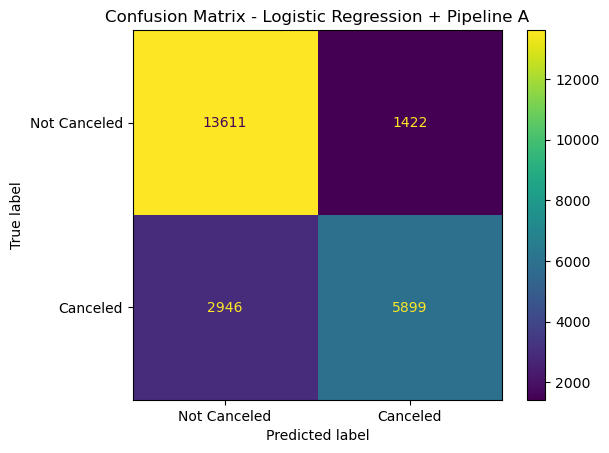

<Figure size 600x500 with 0 Axes>

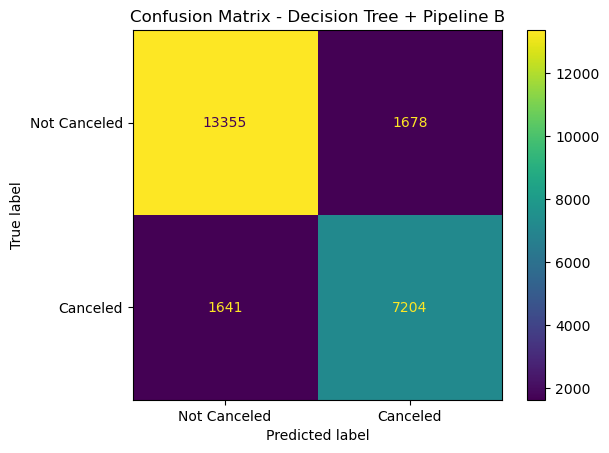


OVERFITTING ANALYSIS

Logistic Regression + Pipeline A
Train-Test Difference: 0.0018
Small train-test difference; little evidence of overfitting.

Logistic Regression + Pipeline B
Train-Test Difference: 0.0024
Small train-test difference; little evidence of overfitting.

Decision Tree + Pipeline A
Train-Test Difference: 0.1353
Large train-test difference; possible overfitting.

Decision Tree + Pipeline B
Train-Test Difference: 0.1352
Large train-test difference; possible overfitting.


In [8]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# TASK 5 - EVALUATE AND COMPARE THE FOUR RESULTS
# =========================================================

# 1. Store all four trained model-pipeline combinations
models = {
    "Logistic Regression + Pipeline A": logistic_A,
    "Logistic Regression + Pipeline B": logistic_B,
    "Decision Tree + Pipeline A": tree_A,
    "Decision Tree + Pipeline B": tree_B
}


# =========================================================
# 2. Calculate all required evaluation metrics
# =========================================================

results = []

for name, model in models.items():

    # Predictions on training and testing data
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training accuracy
    train_accuracy = accuracy_score(y_train, y_train_pred)

    # Testing accuracy
    test_accuracy = accuracy_score(y_test, y_test_pred)

    # Testing precision, recall and F1-score
    precision = precision_score(y_test, y_test_pred, zero_division=0)
    recall = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)

    # Difference between training and testing accuracy
    train_test_difference = train_accuracy - test_accuracy

    results.append({
        "Model": name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Train-Test Difference": train_test_difference
    })


# =========================================================
# 3. Create final comparison table
# =========================================================

results_df = pd.DataFrame(results)

print("FINAL MODEL COMPARISON")
print("=" * 80)

display(results_df.round(4))


# =========================================================
# 4. Find the best Logistic Regression result
#    and best Decision Tree result using F1-score
# =========================================================

logistic_results = results_df[
    results_df["Model"].str.contains("Logistic Regression")
]

tree_results = results_df[
    results_df["Model"].str.contains("Decision Tree")
]

best_logistic = logistic_results.loc[
    logistic_results["F1-Score"].idxmax()
]

best_tree = tree_results.loc[
    tree_results["F1-Score"].idxmax()
]

print("\nBEST LOGISTIC REGRESSION RESULT")
print("=" * 50)
print(best_logistic.round(4))

print("\nBEST DECISION TREE RESULT")
print("=" * 50)
print(best_tree.round(4))


# =========================================================
# 5. Get the actual best trained models
# =========================================================

best_logistic_name = best_logistic["Model"]
best_tree_name = best_tree["Model"]

best_logistic_model = models[best_logistic_name]
best_tree_model = models[best_tree_name]


# =========================================================
# 6. Predictions for confusion matrices
# =========================================================

y_logistic_pred = best_logistic_model.predict(X_test)
y_tree_pred = best_tree_model.predict(X_test)


# =========================================================
# 7. Confusion Matrix - Best Logistic Regression
# =========================================================

cm_logistic = confusion_matrix(y_test, y_logistic_pred)

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not Canceled", "Canceled"]
).plot()

plt.title(f"Confusion Matrix - {best_logistic_name}")
plt.show()


# =========================================================
# 8. Confusion Matrix - Best Decision Tree
# =========================================================

cm_tree = confusion_matrix(y_test, y_tree_pred)

plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Not Canceled", "Canceled"]
).plot()

plt.title(f"Confusion Matrix - {best_tree_name}")
plt.show()


# =========================================================
# 9. Comment on possible overfitting
# =========================================================

print("\nOVERFITTING ANALYSIS")
print("=" * 50)

for _, row in results_df.iterrows():

    difference = row["Train-Test Difference"]

    if difference < 0.05:
        comment = "Small train-test difference; little evidence of overfitting."
    elif difference < 0.10:
        comment = "Moderate train-test difference; some possible overfitting."
    else:
        comment = "Large train-test difference; possible overfitting."

    print(f"\n{row['Model']}")
    print(f"Train-Test Difference: {difference:.4f}")
    print(comment)

### Task 6 - Final Observations

In [9]:
# =========================================================
# TASK 6 - FINAL OBSERVATIONS
# =========================================================

# Best overall model based on F1-score
best_overall = results_df.loc[results_df["F1-Score"].idxmax()]

print("BEST OVERALL RESULT")
print("=" * 50)
print(best_overall.round(4))


# ---------------------------------------------------------
# Compare StandardScaler vs MinMaxScaler for Logistic Regression
# ---------------------------------------------------------

logistic_A_result = results_df[
    results_df["Model"] == "Logistic Regression + Pipeline A"
].iloc[0]

logistic_B_result = results_df[
    results_df["Model"] == "Logistic Regression + Pipeline B"
].iloc[0]

print("\nLOGISTIC REGRESSION COMPARISON")
print("=" * 50)

print(f"Pipeline A (StandardScaler) F1-score: "
      f"{logistic_A_result['F1-Score']:.4f}")

print(f"Pipeline B (MinMaxScaler) F1-score: "
      f"{logistic_B_result['F1-Score']:.4f}")

if logistic_A_result["F1-Score"] > logistic_B_result["F1-Score"]:
    print("StandardScaler gives the better Logistic Regression result.")
elif logistic_B_result["F1-Score"] > logistic_A_result["F1-Score"]:
    print("MinMaxScaler gives the better Logistic Regression result.")
else:
    print("Both scalers give the same Logistic Regression F1-score.")


# ---------------------------------------------------------
# Compare scaling effect on Decision Tree
# ---------------------------------------------------------

tree_A_result = results_df[
    results_df["Model"] == "Decision Tree + Pipeline A"
].iloc[0]

tree_B_result = results_df[
    results_df["Model"] == "Decision Tree + Pipeline B"
].iloc[0]

tree_difference = abs(
    tree_A_result["F1-Score"] - tree_B_result["F1-Score"]
)

print("\nDECISION TREE SCALING COMPARISON")
print("=" * 50)

print(f"Pipeline A (StandardScaler) F1-score: "
      f"{tree_A_result['F1-Score']:.4f}")

print(f"Pipeline B (MinMaxScaler) F1-score: "
      f"{tree_B_result['F1-Score']:.4f}")

print(f"F1-score difference: {tree_difference:.4f}")

if tree_difference < 0.01:
    print("Scaling has very little effect on the Decision Tree.")
else:
    print("Scaling has some effect on the Decision Tree.")


# ---------------------------------------------------------
# Train-test gap
# ---------------------------------------------------------

print("\nTRAIN-TEST PERFORMANCE")
print("=" * 50)

for _, row in results_df.iterrows():
    print(
        f"{row['Model']}: "
        f"Train-Test Difference = {row['Train-Test Difference']:.4f}"
    )

BEST OVERALL RESULT
Model                    Decision Tree + Pipeline B
Training Accuracy                           0.99622
Testing Accuracy                           0.861002
Precision                                  0.811079
Recall                                     0.814471
F1-Score                                   0.812771
Train-Test Difference                      0.135219
Name: 3, dtype: object

LOGISTIC REGRESSION COMPARISON
Pipeline A (StandardScaler) F1-score: 0.7298
Pipeline B (MinMaxScaler) F1-score: 0.7181
StandardScaler gives the better Logistic Regression result.

DECISION TREE SCALING COMPARISON
Pipeline A (StandardScaler) F1-score: 0.8126
Pipeline B (MinMaxScaler) F1-score: 0.8128
F1-score difference: 0.0001
Scaling has very little effect on the Decision Tree.

TRAIN-TEST PERFORMANCE
Logistic Regression + Pipeline A: Train-Test Difference = 0.0018
Logistic Regression + Pipeline B: Train-Test Difference = 0.0024
Decision Tree + Pipeline A: Train-Test Difference = 0.13

## Final Observations
1) Decision Tree with Pipeline B gives the best overall result. It has the highest F1-score of 0.8128 and a testing accuracy of 86.10%, so it performed better than the other three combinations.

2) For Logistic Regression, StandardScaler performed a little better than MinMaxScaler. The F1-score was 0.7298 with StandardScaler compared to 0.7181 with MinMaxScaler. So, the choice of scaling method does make some difference for Logistic Regression.

3) Scaling does not make a major difference for the Decision Tree. Both StandardScaler and MinMaxScaler give almost the same results, with testing accuracy around 86.10% and F1-scores of 0.8126 and 0.8128. So, changing the scaling method has very little effect on the Decision Tree.

4) From the confusion matrices, the Decision Tree was better at identifying canceled bookings than Logistic Regression. It correctly predicted 7,204 canceled bookings, while Logistic Regression correctly predicted 5,899.

5) The Decision Tree has a much larger gap between training and testing accuracy (99.62% vs 86.10%), which suggests that it is overfitting the training data. Logistic Regression has a much smaller gap, so it seems to generalize better to unseen data.